In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re

plt.rcParams["figure.figsize"] = (15,6)
plt.rcParams["font.size"] = 12

In [2]:
# Folder 1983–1990
folder1 = "/Users/jyotikotnala/Downloads/ISCCP_HGM_1983_1990"

# Folder 1990–2017
folder2 = "/Users/jyotikotnala/Downloads/ISCCP_HGM_1990_2017"

files = sorted(glob.glob(folder1+"/*.nc"))
files += sorted(glob.glob(folder2+"/*.nc"))

print("Files =",len(files))

isccp_ds = xr.open_mfdataset(

    files,

    combine="nested",

    concat_dim="time"

)

print(isccp_ds)

Files = 420
<xarray.Dataset> Size: 17GB
Dimensions:             (time: 420, satpos: 12, eqcell: 41252, eqzone: 180,
                         lon: 360, edge: 2, lat: 180, cldbin: 10,
                         cloud_irtype: 3, cloud_type: 18, count: 256,
                         levtmp: 16, levrh: 16)
Coordinates:
  * lon                 (lon) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * lat                 (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * cldbin              (cldbin) int16 20B 5 15 25 35 45 55 65 75 85 95
  * levtmp              (levtmp) float32 64B 900.0 800.0 740.0 ... 50.0 10.0
  * levrh               (levrh) float32 64B 900.0 800.0 740.0 ... 50.0 10.0
Dimensions without coordinates: time, satpos, eqcell, eqzone, edge,
                                cloud_irtype, cloud_type, count
Data variables: (12/103)
    satcodes            (time, satpos) int16 10kB dask.array<chunksize=(1, 12), meta=np.ndarray>
    satids              (time, satpos) |S4 20kB 

In [3]:
ceres = xr.open_dataset(

"/Users/jyotikotnala/Downloads/CERES_SYN1deg-Month_Terra-Aqua-NOAA20_Ed4.2_Subset_200101-202512.nc"

)

print(ceres)

<xarray.Dataset> Size: 78MB
Dimensions:            (lon: 360, lat: 180, time: 300)
Coordinates:
  * lon                (lon) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * lat                (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * time               (time) datetime64[ns] 2kB 2001-01-15 ... 2025-12-15
Data variables:
    cldarea_total_mon  (time, lat, lon) float32 78MB ...
Attributes:
    title:        CERES SYN1deg Products - Monthly Means
    institution:  NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:  CF-1.4
    comment:      Satellites used: Terra 3/2000 - 6/2002; Terra+Aqua 7/2002 -...
    Version:      Edition 4.2; Release Date May 7, 2025
    DOI:          10.5067/Terra-Aqua-NOAA20/CERES/SYN1degMonth_L3.004B
    Fill_Value:   Fill Value is -999.0


In [4]:
ukesm_hist = xr.open_dataset(

"/Users/jyotikotnala/Downloads/cloudfraction /clt_Amon_UKESM1-0-LL_historical_r1i1p1f2_gn_195001-201412 (1).nc"

)

ukesm_ssp = xr.open_dataset(

"/Users/jyotikotnala/Downloads/cloudfraction /clt_Amon_UKESM1-0-LL_ssp245_r1i1p1f2_gn_201501-204912.nc"

)

ukesm_ds = xr.concat(

[ukesm_hist,ukesm_ssp],

dim="time"

)

ukesm_ds = ukesm_ds.sel(

time=slice("1983","2025")

)

print(ukesm_ds)

<xarray.Dataset> Size: 60MB
Dimensions:    (time: 516, bnds: 2, lat: 144, lon: 192)
Coordinates:
  * time       (time) object 4kB 1983-01-16 00:00:00 ... 2025-12-16 00:00:00
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 8kB 1983-01-01 00:00:00 ... 2026-01-01 00:...
    lat_bnds   (time, lat, bnds) float64 1MB -90.0 -88.75 -88.75 ... 88.75 90.0
    lon_bnds   (time, lon, bnds) float64 2MB 0.0 1.875 1.875 ... 358.1 360.0
    clt        (time, lat, lon) float32 57MB 80.08 79.91 80.07 ... 93.47 93.88
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  144000.0
    creation_date:          2019-04-05T16:39:33Z
    ...                     ...
    title:      

In [5]:
ipsl_hist = xr.open_dataset(

"/Users/jyotikotnala/Downloads/cloudfraction /clt_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc"

)

ipsl_ssp = xr.open_dataset(

"/Users/jyotikotnala/Downloads/cloudfraction /clt_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_201501-210012 (1).nc"

)

ipsl_ds = xr.concat(

[ipsl_hist,ipsl_ssp],

dim="time"

)

ipsl_ds = ipsl_ds.sel(

time=slice("1983","2025")

)

print(ipsl_ds)

<xarray.Dataset> Size: 43MB
Dimensions:      (time: 516, axis_nbounds: 2, lat: 143, lon: 144)
Coordinates:
  * lat          (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon          (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time         (time) datetime64[ns] 4kB 1983-01-16T12:00:00 ... 2025-12-16...
Dimensions without coordinates: axis_nbounds
Data variables:
    time_bounds  (time, axis_nbounds) datetime64[ns] 8kB 1983-01-01 ... 2026-...
    clt          (time, lat, lon) float32 43MB 40.63 40.63 40.63 ... 78.97 78.97
Attributes: (12/51)
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2018-07-11T07:36:41Z
    tracking_id:            hdl:21.14100/74af8c68-c2c8-41bc-8bdc-854439e12b1b
    description:            CMIP6 historical
    title:                  IPSL-CM6A-LR model output prepared for CMIP6 / CM...
    activity_id:            CMIP
    ...                     ...
    name:                   /ccc/work/cont003/genc

In [6]:
mri_hist = xr.open_dataset(

"/Users/jyotikotnala/Downloads/cloudfraction /clt_Amon_MRI-ESM2-0_historical_r1i1p1f1_gn_185001-201412 (1).nc"

)

mri_ssp = xr.open_dataset(

"/Users/jyotikotnala/Downloads/cloudfraction /clt_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn_201501-210012.nc"

)

mri_ds = xr.concat(

[mri_hist,mri_ssp],

dim="time"

)

mri_ds = mri_ds.sel(

time=slice("1983","2025")

)

print(mri_ds)

<xarray.Dataset> Size: 110MB
Dimensions:    (time: 516, bnds: 2, lat: 160, lon: 320)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1983-01-16T12:00:00 ... 2025-12-16T1...
  * lat        (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
  * lon        (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 356.6 357.8 358.9
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 8kB 1983-01-01 ... 2026-01-01
    lat_bnds   (time, lat, bnds) float64 1MB -90.0 -88.59 -88.59 ... 88.59 90.0
    lon_bnds   (time, lon, bnds) float64 3MB -0.5625 0.5625 ... 358.3 359.4
    clt        (time, lat, lon) float32 106MB 26.73 26.87 26.87 ... 59.36 59.34
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-02-20T02:47:34Z
    ...                     ...
    title:                  

In [7]:
print(isccp_ds)

print(ceres)

print(ukesm_ds)

print(ipsl_ds)

print(mri_ds)

<xarray.Dataset> Size: 17GB
Dimensions:             (time: 420, satpos: 12, eqcell: 41252, eqzone: 180,
                         lon: 360, edge: 2, lat: 180, cldbin: 10,
                         cloud_irtype: 3, cloud_type: 18, count: 256,
                         levtmp: 16, levrh: 16)
Coordinates:
  * lon                 (lon) float32 1kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * lat                 (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * cldbin              (cldbin) int16 20B 5 15 25 35 45 55 65 75 85 95
  * levtmp              (levtmp) float32 64B 900.0 800.0 740.0 ... 50.0 10.0
  * levrh               (levrh) float32 64B 900.0 800.0 740.0 ... 50.0 10.0
Dimensions without coordinates: time, satpos, eqcell, eqzone, edge,
                                cloud_irtype, cloud_type, count
Data variables: (12/103)
    satcodes            (time, satpos) int16 10kB dask.array<chunksize=(1, 12), meta=np.ndarray>
    satids              (time, satpos) |S4 20kB dask.array<c

In [8]:
# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

import numpy as np
import pandas as pd
import xarray as xr

# ----------------------------------------------------------
# 1. ISCCP regional mean (eqcell)
# ----------------------------------------------------------

def isccp_region(lat1, lat2):

    # Latitude of each equal-area cell
    lat = isccp_ds["eqlat"].isel(time=0)

    # Mask
    mask = (lat >= lat1) & (lat <= lat2)

    # Mean over equal-area cells
    da = (
        isccp_ds["cldamt"]
        .where(mask)
        .mean("eqcell")
    )

    # Monthly dates
    dates = pd.date_range(
        start="1983-07-15",
        periods=da.sizes["time"],
        freq="MS"
    ) + pd.Timedelta(days=14)

    da = da.assign_coords(time=dates)

    return da


# ----------------------------------------------------------
# 2. CERES regional mean
# ----------------------------------------------------------

def ceres_region(lat1, lat2):

    region = ceres.sel(lat=slice(lat1, lat2))

    weights = np.cos(np.deg2rad(region.lat))

    da = (
        region["cldarea_total_mon"]
        .weighted(weights)
        .mean(("lat", "lon"))
    )

    return da


# ----------------------------------------------------------
# 3. UKESM regional mean
# ----------------------------------------------------------

def ukesm_region(lat1, lat2):

    region = ukesm_ds.sel(lat=slice(lat1, lat2))

    weights = np.cos(np.deg2rad(region.lat))

    da = (
        region["clt"]
        .weighted(weights)
        .mean(("lat", "lon"))
    )

    return da


# ----------------------------------------------------------
# 4. IPSL regional mean
# ----------------------------------------------------------

def ipsl_region(lat1, lat2):

    region = ipsl_ds.sel(lat=slice(lat1, lat2))

    weights = np.cos(np.deg2rad(region.lat))

    da = (
        region["clt"]
        .weighted(weights)
        .mean(("lat", "lon"))
    )

    return da


# ----------------------------------------------------------
# 5. MRI regional mean
# ----------------------------------------------------------

def mri_region(lat1, lat2):

    region = mri_ds.sel(lat=slice(lat1, lat2))

    weights = np.cos(np.deg2rad(region.lat))

    da = (
        region["clt"]
        .weighted(weights)
        .mean(("lat", "lon"))
    )

    return da

print("✓ All helper functions created successfully")

✓ All helper functions created successfully


In [9]:
# Test Tropics

isccp_test = isccp_region(-30,30)
ceres_test = ceres_region(-30,30)
ukesm_test = ukesm_region(-30,30)
ipsl_test = ipsl_region(-30,30)
mri_test = mri_region(-30,30)

print(isccp_test)
print(ceres_test)
print(ukesm_test)
print(ipsl_test)
print(mri_test)

<xarray.DataArray 'cldamt' (time: 420)> Size: 3kB
dask.array<mean_agg-aggregate, shape=(420,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1983-08-15 1983-09-15 ... 2018-07-15
<xarray.DataArray 'cldarea_total_mon' (time: 300)> Size: 1kB
array([60.56377 , 61.20836 , 59.616806, 59.870625, 59.636124, 60.907043,
       61.634476, 62.594597, 61.061947, 61.48428 , 61.86465 , 62.93655 ,
       61.291206, 60.860054, 59.48875 , 59.137833, 58.813686, 61.813755,
       62.08506 , 62.531315, 61.83532 , 60.957535, 62.76477 , 62.098167,
       62.53504 , 60.63214 , 58.751686, 59.646683, 60.962135, 60.962475,
       62.078793, 61.614212, 62.28598 , 61.76674 , 62.20404 , 63.275227,
       63.272057, 60.124317, 62.571724, 61.366337, 61.424965, 62.58477 ,
       62.249287, 61.01064 , 61.34667 , 61.730194, 62.515392, 62.891727,
       62.461864, 60.82541 , 59.065384, 61.057262, 61.520046, 62.938362,
       62.410828, 61.272655, 61.716698, 60

In [10]:
# ==========================================================
# HARMONIZE ISCCP + CERES
# ==========================================================

def harmonize_obs(lat1, lat2):

    # Regional means
    isccp = isccp_region(lat1, lat2)
    ceres_reg = ceres_region(lat1, lat2)

    # Common overlap
    overlap_start = "2001-01-15"
    overlap_end = "2017-12-15"

    isccp_overlap = isccp.sel(
        time=slice(overlap_start, overlap_end)
    )

    ceres_overlap = ceres_reg.sel(
        time=slice(overlap_start, overlap_end)
    )

    # Bias correction
    bias = (
        ceres_overlap.mean().compute().item()
        -
        isccp_overlap.mean().compute().item()
    )

    print("Bias =", bias)

    # Shift ISCCP
    isccp = isccp + bias

    # Keep only pre-CERES period
    isccp = isccp.sel(
        time=slice("1983-07-15", "2000-12-15")
    )

    # Merge
    obs = xr.concat(
        [
            isccp,
            ceres_reg
        ],
        dim="time"
    )

    # Remove duplicate dates
    _, index = np.unique(
        obs.time,
        return_index=True
    )

    obs = obs.isel(time=index)

    obs = obs.sortby("time")

    return obs

In [11]:
obs_tropics = harmonize_obs(-30, 30)

print(obs_tropics)

Bias = 2.4509245154997146
<xarray.DataArray 'cldamt' (time: 509)> Size: 4kB
dask.array<getitem, shape=(509,), dtype=float64, chunksize=(300,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1983-08-15 1983-09-15 ... 2025-12-15


In [12]:
# ==========================================================
# TROPICAL MODEL MEANS
# ==========================================================

ukesm_tropics = ukesm_region(-30,30)

ipsl_tropics = ipsl_region(-30,30)

mri_tropics = mri_region(-30,30)

print(ukesm_tropics.shape)
print(ipsl_tropics.shape)
print(mri_tropics.shape)

(516,)
(516,)
(516,)


In [14]:
# Convert to NumPy-backed arrays
obs_plot = obs_tropics.compute()

ukesm_plot = ukesm_tropics.compute()
ipsl_plot = ipsl_tropics.compute()
mri_plot = mri_tropics.compute()

In [15]:
obs_sm = obs_plot.rolling(
    time=12,
    center=True,
    min_periods=1
).mean()

ukesm_sm = ukesm_plot.rolling(
    time=12,
    center=True,
    min_periods=1
).mean()

ipsl_sm = ipsl_plot.rolling(
    time=12,
    center=True,
    min_periods=1
).mean()

mri_sm = mri_plot.rolling(
    time=12,
    center=True,
    min_periods=1
).mean()

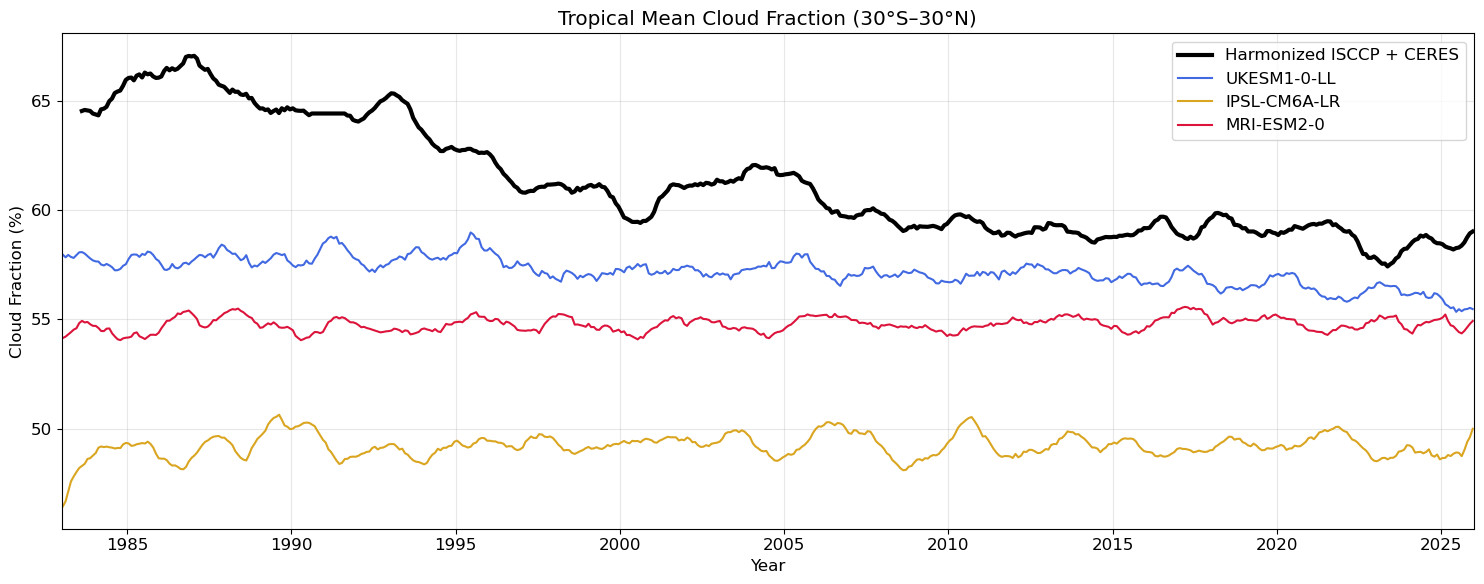

In [16]:
plt.figure(figsize=(15,6))

plt.plot(obs_sm.time.values, obs_sm.values,
         color="black", linewidth=3,
         label="Harmonized ISCCP + CERES")

plt.plot(ukesm_sm.time.values, ukesm_sm.values,
         color="royalblue", label="UKESM1-0-LL")

plt.plot(ipsl_sm.time.values, ipsl_sm.values,
         color="goldenrod", label="IPSL-CM6A-LR")

plt.plot(mri_sm.time.values, mri_sm.values,
         color="crimson", label="MRI-ESM2-0")

plt.xlim(pd.Timestamp("1983-01-01"),
         pd.Timestamp("2025-12-31"))

plt.grid(alpha=0.3)
plt.xlabel("Year")
plt.ylabel("Cloud Fraction (%)")
plt.title("Tropical Mean Cloud Fraction (30°S–30°N)")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Northern subtropics
obs_sub_n = harmonize_obs(30, 60)

# Southern subtropics
obs_sub_s = harmonize_obs(-60, -30)

# Average both hemispheres
obs_subtropics = (obs_sub_n + obs_sub_s) / 2

print(obs_subtropics)

Bias = -0.20290246290043967
Bias = 2.3145185674855213
<xarray.DataArray 'cldamt' (time: 509)> Size: 4kB
dask.array<truediv, shape=(509,), dtype=float64, chunksize=(300,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1983-08-15 1983-09-15 ... 2025-12-15


In [18]:
ukesm_sub_n = ukesm_region(30,60)
ukesm_sub_s = ukesm_region(-60,-30)

ukesm_subtropics = (ukesm_sub_n + ukesm_sub_s)/2

In [19]:
ipsl_sub_n = ipsl_region(30,60)
ipsl_sub_s = ipsl_region(-60,-30)

ipsl_subtropics = (ipsl_sub_n + ipsl_sub_s)/2

In [20]:
mri_sub_n = mri_region(30,60)
mri_sub_s = mri_region(-60,-30)

mri_subtropics = (mri_sub_n + mri_sub_s)/2

In [21]:
obs_subtropics = obs_subtropics.compute()

ukesm_subtropics = ukesm_subtropics.compute()

ipsl_subtropics = ipsl_subtropics.compute()

mri_subtropics = mri_subtropics.compute()

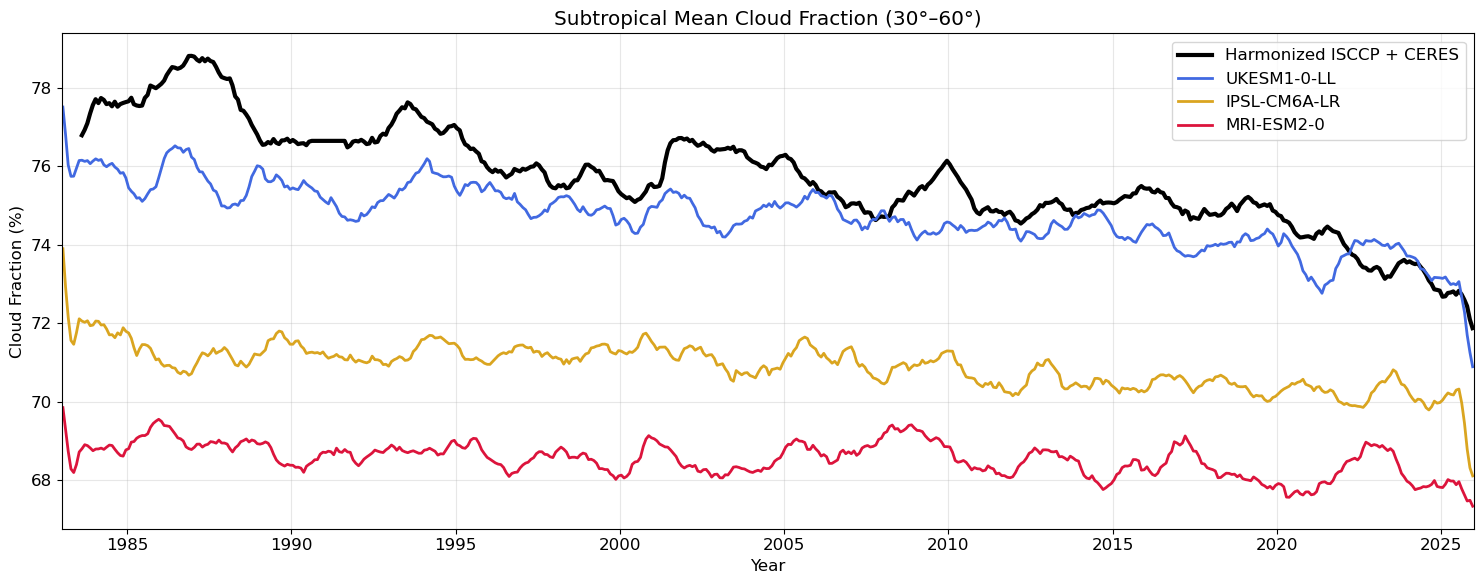

In [22]:
plt.figure(figsize=(15,6))

plt.plot(
    obs_subtropics.time,
    obs_subtropics.rolling(time=12,center=True,min_periods=1).mean(),
    color="black",
    linewidth=3,
    label="Harmonized ISCCP + CERES"
)

plt.plot(
    ukesm_subtropics.time,
    ukesm_subtropics.rolling(time=12,center=True,min_periods=1).mean(),
    color="royalblue",
    linewidth=2,
    label="UKESM1-0-LL"
)

plt.plot(
    ipsl_subtropics.time,
    ipsl_subtropics.rolling(time=12,center=True,min_periods=1).mean(),
    color="goldenrod",
    linewidth=2,
    label="IPSL-CM6A-LR"
)

plt.plot(
    mri_subtropics.time,
    mri_subtropics.rolling(time=12,center=True,min_periods=1).mean(),
    color="crimson",
    linewidth=2,
    label="MRI-ESM2-0"
)

plt.xlim(pd.Timestamp("1983-01-01"),
         pd.Timestamp("2025-12-31"))

plt.grid(alpha=0.3)

plt.xlabel("Year")

plt.ylabel("Cloud Fraction (%)")

plt.title("Subtropical Mean Cloud Fraction (30°–60°)")

plt.legend()

plt.tight_layout()

plt.show()

In [23]:
# ==========================================================
# MID-LATITUDES (30°–60° N & S)
# ==========================================================

obs_mid_n = harmonize_obs(30, 60)

obs_mid_s = harmonize_obs(-60, -30)

obs_mid = (obs_mid_n + obs_mid_s) / 2

obs_mid = obs_mid.compute()

print(obs_mid)

Bias = -0.20290246290043967
Bias = 2.3145185674855213
<xarray.DataArray 'cldamt' (time: 509)> Size: 4kB
array([76.29346966, 75.59908706, 77.29711266, 77.45373926, 77.94689144,
       76.16924701, 77.75482711, 78.26620636, 79.36091599, 79.46677888,
       79.21878682, 76.53572432, 77.83615035, 75.02585047, 76.00414493,
       77.74908226, 76.98639121, 77.57378366, 76.23054488, 79.05057256,
       79.71274689, 79.73751317, 79.46073844, 77.61935508, 75.86219972,
       74.63910317, 75.84161238, 77.88355416, 79.31669373, 78.49735321,
       79.10350414, 78.67052908, 79.28463779, 80.37215319, 80.16448781,
       78.6099303 , 77.52196698, 75.9427452 , 77.00036498, 77.6981124 ,
       78.98475674, 78.81253277, 79.76320057, 79.99571649, 80.89724915,
       80.41251802, 79.93555433, 77.65277896, 77.01593781, 76.93951751,
       76.04418858, 78.49839276, 78.25932918, 78.50169036, 78.28534091,
       78.2720978 , 79.51942712, 80.08531171, 79.65793101, 77.82698606,
       74.95103767, 73.506439  ,

In [24]:
ukesm_mid_n = ukesm_region(30,60)

ukesm_mid_s = ukesm_region(-60,-30)

ukesm_mid = (ukesm_mid_n + ukesm_mid_s)/2

ukesm_mid = ukesm_mid.compute()

In [25]:
ipsl_mid_n = ipsl_region(30,60)

ipsl_mid_s = ipsl_region(-60,-30)

ipsl_mid = (ipsl_mid_n + ipsl_mid_s)/2

ipsl_mid = ipsl_mid.compute()

In [26]:
mri_mid_n = mri_region(30,60)

mri_mid_s = mri_region(-60,-30)

mri_mid = (mri_mid_n + mri_mid_s)/2

mri_mid = mri_mid.compute()

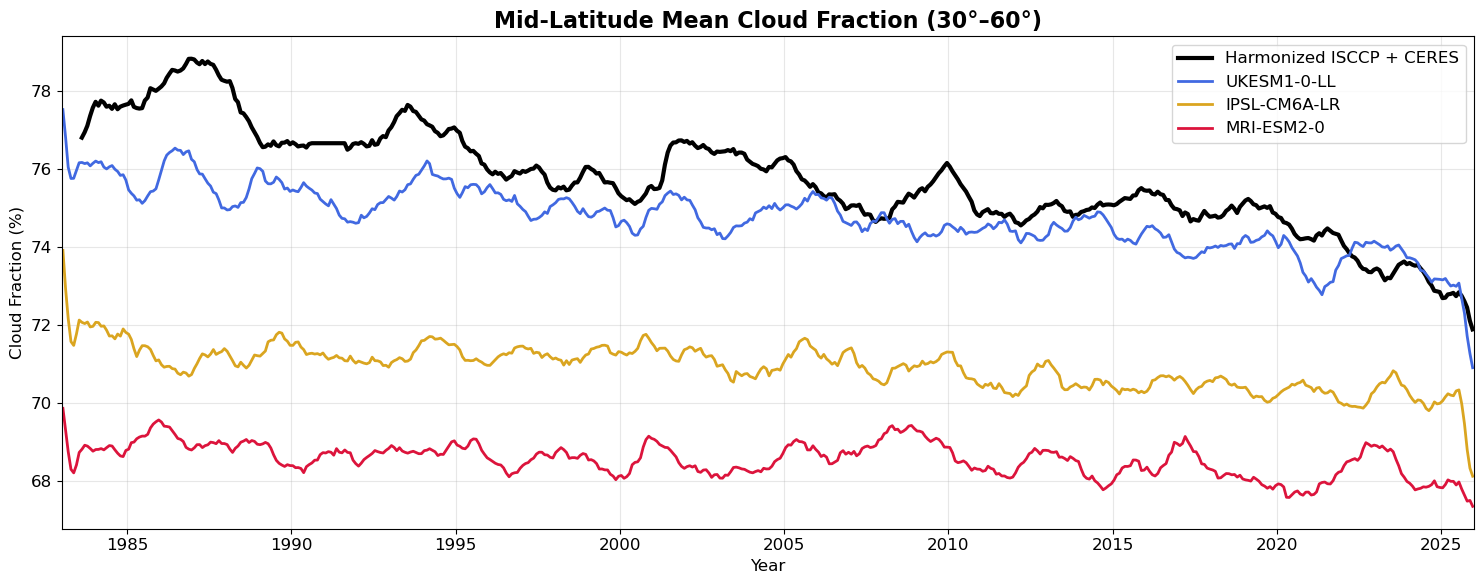

In [27]:
plt.figure(figsize=(15,6))

plt.plot(
    obs_mid.time,
    obs_mid.rolling(time=12,center=True,min_periods=1).mean(),
    color="black",
    linewidth=3,
    label="Harmonized ISCCP + CERES"
)

plt.plot(
    ukesm_mid.time,
    ukesm_mid.rolling(time=12,center=True,min_periods=1).mean(),
    color="royalblue",
    linewidth=2,
    label="UKESM1-0-LL"
)

plt.plot(
    ipsl_mid.time,
    ipsl_mid.rolling(time=12,center=True,min_periods=1).mean(),
    color="goldenrod",
    linewidth=2,
    label="IPSL-CM6A-LR"
)

plt.plot(
    mri_mid.time,
    mri_mid.rolling(time=12,center=True,min_periods=1).mean(),
    color="crimson",
    linewidth=2,
    label="MRI-ESM2-0"
)

plt.xlim(pd.Timestamp("1983-01-01"),
         pd.Timestamp("2025-12-31"))

plt.grid(alpha=0.3)

plt.xlabel("Year")

plt.ylabel("Cloud Fraction (%)")

plt.title(
    "Mid-Latitude Mean Cloud Fraction (30°–60°)",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()

In [28]:
# ==========================================================
# POLAR REGIONS (60°–90° N & S)
# ==========================================================

obs_pol_n = harmonize_obs(60,90)

obs_pol_s = harmonize_obs(-90,-60)

obs_polar = (obs_pol_n + obs_pol_s)/2

obs_polar = obs_polar.compute()

print(obs_polar)

Bias = 4.98082312910671
Bias = 7.433625398627626
<xarray.DataArray 'cldamt' (time: 509)> Size: 4kB
array([76.08319241, 77.17059741, 75.64321775, 76.24072046, 70.18483918,
       70.96938496, 70.71098829, 71.84918952, 75.60999299, 73.06614573,
       73.00769477, 73.3410462 , 76.38263143, 78.3274378 , 76.5973618 ,
       74.6410281 , 69.33114754, 70.00693472, 71.97997128, 71.81075304,
       74.58069513, 71.04048521, 71.63766219, 74.05434696, 75.65590324,
       76.19801326, 76.92816165, 73.9070252 , 71.22933791, 68.7914986 ,
       73.5220813 , 73.8337353 , 73.39951525, 73.35224779, 72.11133212,
       76.04844757, 77.75335166, 78.39421304, 77.49578742, 74.69015948,
       69.99117287, 72.83842224, 75.00954059, 75.02173747, 77.50476317,
       72.85233827, 73.10820146, 75.24184243, 75.62857787, 77.26343129,
       76.21391988, 74.99450258, 71.48342767, 69.15765857, 72.51581999,
       74.88469441, 74.95755   , 74.52327566, 72.52284135, 74.98145517,
       75.18331909, 77.33938134, 76.0

In [29]:
ukesm_pol_n = ukesm_region(60,90)

ukesm_pol_s = ukesm_region(-90,-60)

ukesm_polar = (ukesm_pol_n + ukesm_pol_s)/2

ukesm_polar = ukesm_polar.compute()

In [30]:
ipsl_pol_n = ipsl_region(60,90)

ipsl_pol_s = ipsl_region(-90,-60)

ipsl_polar = (ipsl_pol_n + ipsl_pol_s)/2

ipsl_polar = ipsl_polar.compute()

In [31]:
mri_pol_n = mri_region(60,90)

mri_pol_s = mri_region(-90,-60)

mri_polar = (mri_pol_n + mri_pol_s)/2

mri_polar = mri_polar.compute()

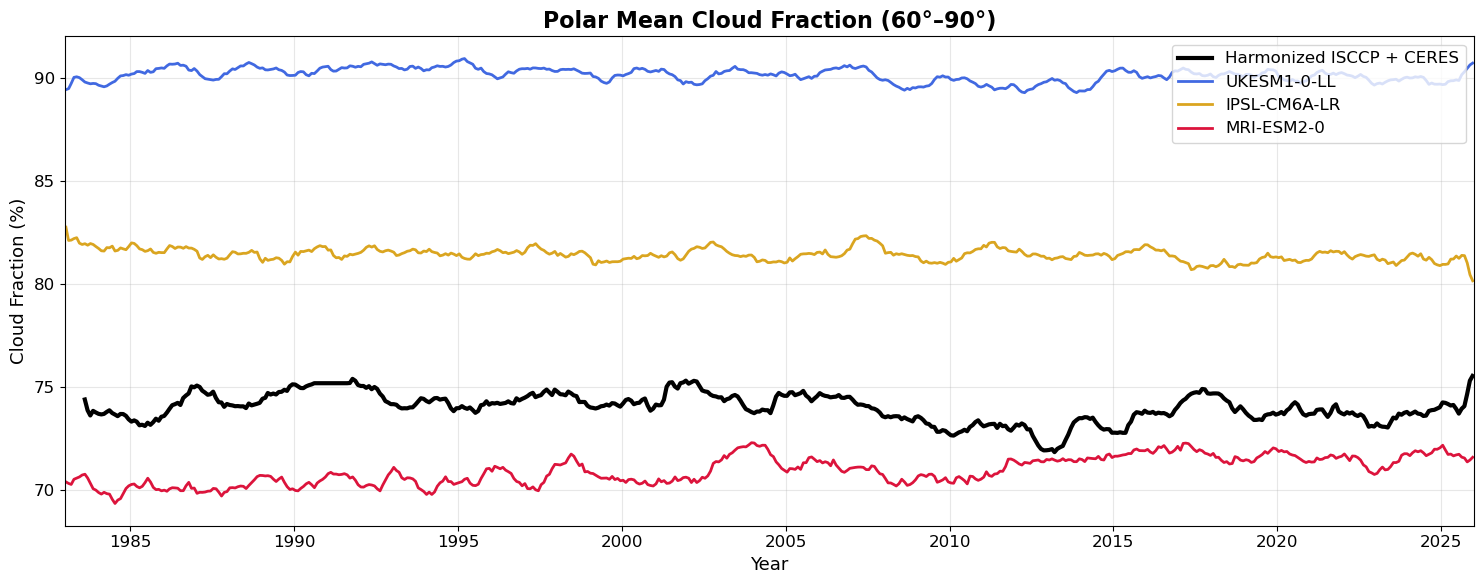

In [32]:
plt.figure(figsize=(15,6))

plt.plot(
    obs_polar.time,
    obs_polar.rolling(time=12,center=True,min_periods=1).mean(),
    color="black",
    linewidth=3,
    label="Harmonized ISCCP + CERES"
)

plt.plot(
    ukesm_polar.time,
    ukesm_polar.rolling(time=12,center=True,min_periods=1).mean(),
    color="royalblue",
    linewidth=2,
    label="UKESM1-0-LL"
)

plt.plot(
    ipsl_polar.time,
    ipsl_polar.rolling(time=12,center=True,min_periods=1).mean(),
    color="goldenrod",
    linewidth=2,
    label="IPSL-CM6A-LR"
)

plt.plot(
    mri_polar.time,
    mri_polar.rolling(time=12,center=True,min_periods=1).mean(),
    color="crimson",
    linewidth=2,
    label="MRI-ESM2-0"
)

plt.xlim(pd.Timestamp("1983-01-01"),
         pd.Timestamp("2025-12-31"))

plt.grid(alpha=0.3)

plt.xlabel("Year", fontsize=13)

plt.ylabel("Cloud Fraction (%)", fontsize=13)

plt.title(
    "Polar Mean Cloud Fraction (60°–90°)",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()